# CNN Multi Classification
다중분류

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

# 데이터 불러오기

In [ ]:
!gdown https://drive.google.com/uc?id=14QMnMDzWqOvAt4b5NA61wbwIyQtRmlmL

Downloading...
From (original): https://drive.google.com/uc?id=14QMnMDzWqOvAt4b5NA61wbwIyQtRmlmL
From (redirected): https://drive.google.com/uc?id=14QMnMDzWqOvAt4b5NA61wbwIyQtRmlmL&confirm=t&uuid=4e605362-557d-47dd-9f8e-78347c10a916
To: /content/cifar10.zip
100% 146M/146M [00:00<00:00, 253MB/s]


In [ ]:
!unzip cifar10.zip

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
CLASS_NAME = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

In [ ]:
import os
from keras.utils import load_img, img_to_array

def _load_split(split_dir, image_size=(32, 32)):
    """train 또는 test 폴더 하나를 (X, y) numpy 배열로 로딩."""
    images, labels = [], []
    for label, class_name in enumerate(CLASS_NAME):
        class_dir = os.path.join(split_dir, class_name)
        print(class_dir)
        # 파일명 정렬(0001.png, 0002.png ...) 후 순서대로 로딩
        for fname in sorted(os.listdir(class_dir)):
            fpath = os.path.join(class_dir, fname)
            img = load_img(fpath, target_size=image_size)   # PIL 이미지
            images.append(img_to_array(img, dtype="uint8")) # (32,32,3)
            labels.append(label)

    X = np.stack(images, axis=0)                            # (N,32,32,3)
    y = np.array(labels, dtype="uint8").reshape(-1, 1)      # (N,1)
    return X, y


def load_data(base_dir=None, image_size=(32, 32)):
    if base_dir is None:
        base_dir = "/content/cifar10"

    x_train, y_train = _load_split(os.path.join(base_dir, "train"), image_size)
    x_test,  y_test  = _load_split(os.path.join(base_dir, "test"),  image_size)
    return (x_train, y_train), (x_test, y_test)


In [ ]:
(x_train, y_train), (x_test, y_test) = load_data()

/content/cifar10/train/airplane
/content/cifar10/train/automobile
/content/cifar10/train/bird
/content/cifar10/train/cat
/content/cifar10/train/deer
/content/cifar10/train/dog
/content/cifar10/train/frog
/content/cifar10/train/horse
/content/cifar10/train/ship
/content/cifar10/train/truck
/content/cifar10/test/airplane
/content/cifar10/test/automobile
/content/cifar10/test/bird
/content/cifar10/test/cat
/content/cifar10/test/deer
/content/cifar10/test/dog
/content/cifar10/test/frog
/content/cifar10/test/horse
/content/cifar10/test/ship
/content/cifar10/test/truck


In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

## EDA

In [ ]:
pd.Series(y_train.flatten()).value_counts().sort_index()

,count
0,5000
1,5000
2,5000
3,5000
4,5000
5,5000
6,5000
7,5000
8,5000
9,5000


### 랜덤 확인

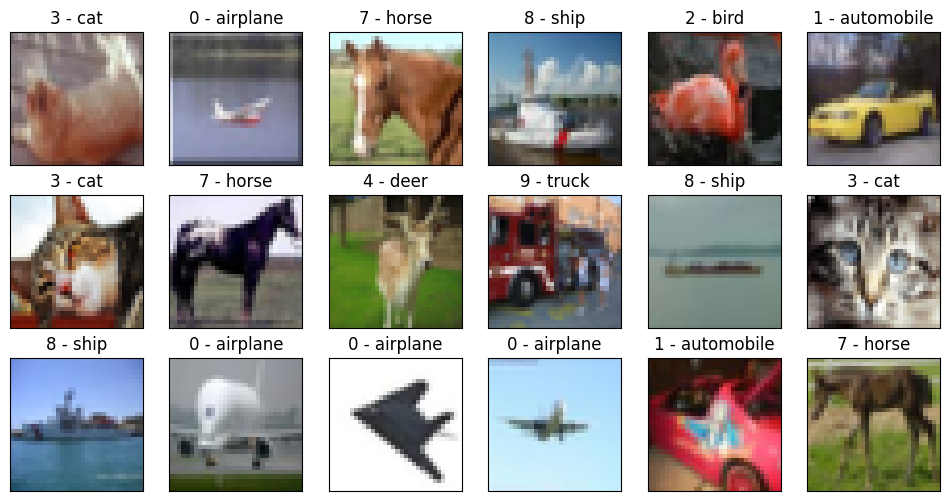

In [ ]:
samples = np.random.randint(len(x_train), size=18)

plt.figure(figsize = (12, 6))
for i, idx in enumerate(samples):
    plt.subplot(3, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(f'{y_train[idx].item()} - {CLASS_NAME[y_train[idx].item()]}')
plt.show()

# 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                  test_size = 0.2, random_state = SEED, shuffle=True)

x_train.shape, x_val.shape, y_train.shape, y_val.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (40000, 1), (10000, 1))

# 전처리

## Scaling

x만 Min Max Scaling 필요

In [ ]:
x_train_s = x_train.astype("float32") / 255.0
x_val_s = x_val.astype("float32") / 255.0

## Encoding

y를 one hot encoding 해야함.

### 함수로 one hot encoding 자동으로 되도록 하려면?
위 셀 없이 나중에 Loss Function 내부에서 one hot encoding 처리

one hot encoding 안한 지금까지의 최종데이터 : x_train_s, x_val_s, y_train, y_test

# 모델 정의

In [ ]:
from keras import layers

def build_basic_model():
  model = keras.Sequential([

   keras.Input(shape=(32, 32, 3)),    # 위에서 데이터셋 크기가 32,32,3 이었음
   layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),

   layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
   layers.MaxPooling2D(2),

   layers.Flatten(),
   layers.Dense(16, activation='relu'),

   layers.Dense(10, activation='softmax')   # output layer
  ])
  return model

In [ ]:
model = build_basic_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        18,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,706 (92.60 KB)

 Trainable params: 23,706 (92.60 KB)

 Non-trainable params: 0 (0.00 B)

# 컴파일

optimizer, loss function, metrics


아까 y encoding 안했으니까 여기서 해보자. : loss =
## sparse_categorical_crossentropy

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['acc']
)

# 학습

In [ ]:
EPOCHS = 30

history = model.fit(
    x_train_s, y_train,
    epochs = EPOCHS,
    batch_size = 128,
    validation_data = (x_val_s, y_val)
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - acc: 0.2961 - loss: 1.9152 - val_acc: 0.3976 - val_loss: 1.6362
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - acc: 0.4636 - loss: 1.4953 - val_acc: 0.4898 - val_loss: 1.4291
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.5160 - loss: 1.3534 - val_acc: 0.5271 - val_loss: 1.3295
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5455 - loss: 1.2679 - val_acc: 0.5505 - val_loss: 1.2700
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5675 - loss: 1.2116 - val_acc: 0.5639 - val_loss: 1.2329
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5825 - loss: 1.1693 - val_acc: 0.5740 - val_loss: 1.2002
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5952 - loss: 1.1332 - val_acc: 0.5819 - val_loss: 1.1717
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6074 - loss: 1.1027 - val_acc: 0.5920 - val_loss: 1.1464
Epoch 9/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step 

정확도 70, loss 84.8 정도 나옴

## 학습 결과 그래프

In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

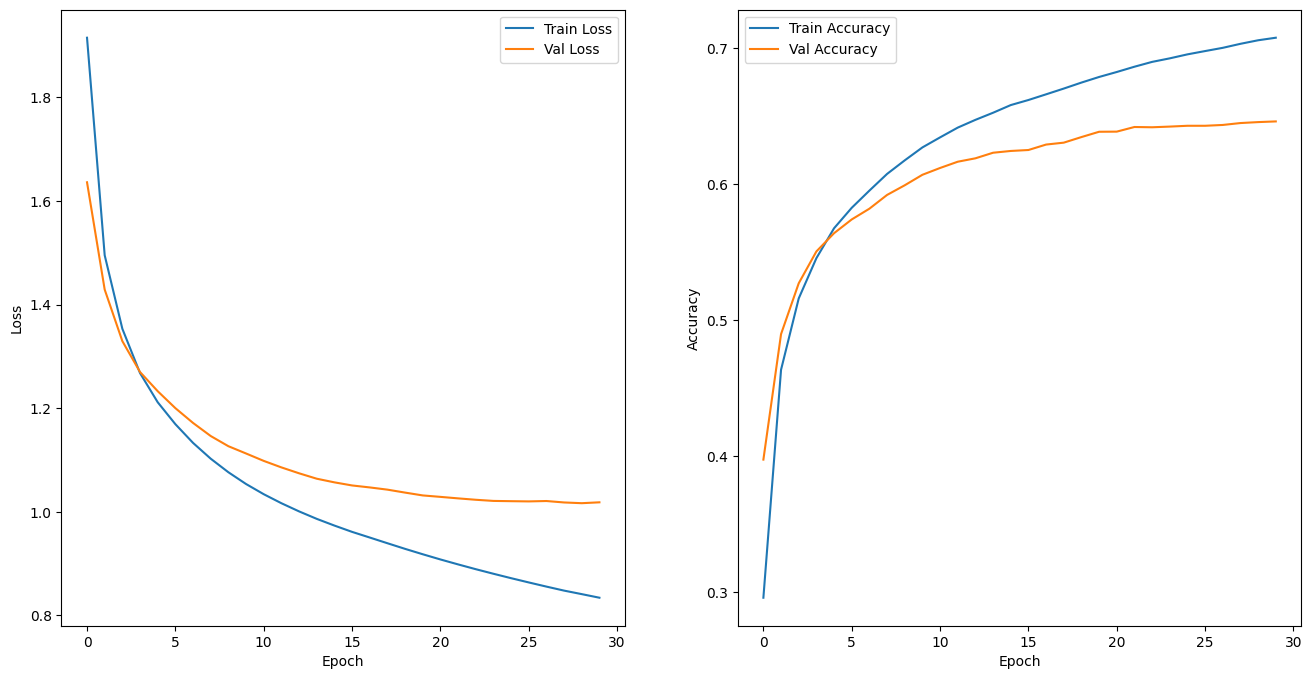

In [ ]:
plot_history(history)

# 테스트

x scaling만

In [ ]:
x_test_s = x_test.astype("float32") / 255.0
y_test = np.asarray(y_test).reshape(-1).astype("int32")

## 돌려보기

In [ ]:
import tensorflow as tf
loss, accuracy = model.evaluate(x_test_s, tf.constant(y_test, dtype=tf.int32))
loss, accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6501 - loss: 1.0223


(1.0222759246826172, 0.6500999927520752)

# Batch Normalization

In [ ]:
from keras import layers, activations

def build_batchnorm_model():
   model = keras.Sequential([
    keras.Input(shape=(32,32,3)),
    layers.Conv2D(filters=16, kernel_size=(3,3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(filters=32, kernel_size=(3,3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation(activations.relu),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(units=16, activation="relu"),
    layers.Dense(units=10, activation="softmax")

    ])
   return model

In [ ]:
model = build_batchnorm_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │        18,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850 (93.16 KB)

 Trainable params: 23,754 (92.79 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["acc"])

In [ ]:
EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    x_train_s, y_train,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = (x_val_s, y_val)
    )

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - acc: 0.4384 - loss: 1.5591 - val_acc: 0.2449 - val_loss: 2.1397
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5692 - loss: 1.2100 - val_acc: 0.5446 - val_loss: 1.2962
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.6153 - loss: 1.0871 - val_acc: 0.5787 - val_loss: 1.2133
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.6429 - loss: 1.0159 - val_acc: 0.5992 - val_loss: 1.1553
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6624 - loss: 0.9660 - val_acc: 0.6050 - val_loss: 1.1385
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6784 - loss: 0.9270 - val_acc: 0.5957 - val_loss: 1.1821
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6899 - loss: 0.8960 - val_acc: 0.5816 - val_loss: 1.2385
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6986 - loss: 0.8705 - val_acc: 0.5835 - val_loss: 1.2384
Epoch 9/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - a

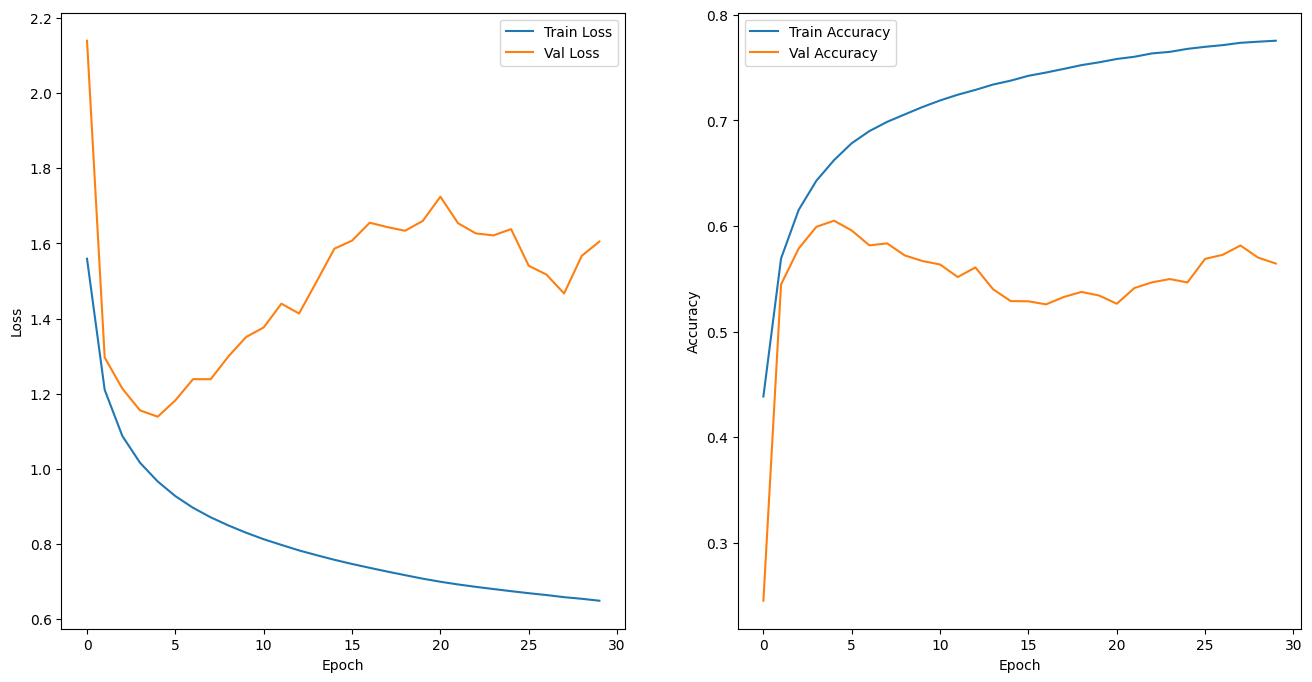

In [ ]:
plot_history(history)

# Transfer Learning 전이학습

대규모 데이터셋으로 이미 학습된 모델을 새로운 유사 문제나 데이터셋에 적용해 성능을 높이는 방법

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape = (32,32,3),   # 학습데이터 이미지 크기
    include_top = False,
    weights = "imagenet",
)

/tmp/ipykernel_42364/3406582592.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [ ]:
base_model.trainable = False
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
def build_transfer_model():

  model = keras.Sequential([
    keras.Input(shape=(32,32,3)),
    base_model,
    layers.Flatten(),
    layers.Dense(units=16, activation="relu"),
    layers.Dense(units=10, activation="softmax")

    ])
  return model

In [ ]:
model = build_transfer_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        20,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,278,650 (8.69 MB)

 Trainable params: 20,666 (80.73 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["acc"])

In [ ]:
EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    x_train_s, y_train,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = (x_val_s, y_val)
    )

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - acc: 0.2288 - loss: 2.1334 - val_acc: 0.2887 - val_loss: 2.0036
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.2962 - loss: 1.9583 - val_acc: 0.3079 - val_loss: 1.9341
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.3075 - loss: 1.9136 - val_acc: 0.3105 - val_loss: 1.9105
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - acc: 0.3149 - loss: 1.8937 - val_acc: 0.3143 - val_loss: 1.8995
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.3178 - loss: 1.8820 - val_acc: 0.3165 - val_loss: 1.8936
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - acc: 0.3194 - loss: 1.8740 - val_acc: 0.3189 - val_loss: 1.8898
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.3219 - loss: 1.8679 - val_acc: 0.3191 - val_loss: 1.8871
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.3239 - loss: 1.8628 - val_acc: 0.3189 - val_loss: 1.8847
Epoch 9/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/st

In [ ]:
loss, accuracy = model.evaluate(x_test_s, tf.constant(y_test, dtype=tf.int32))
loss, accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - acc: 0.3298 - loss: 1.8575


(1.8575314283370972, 0.329800009727478)

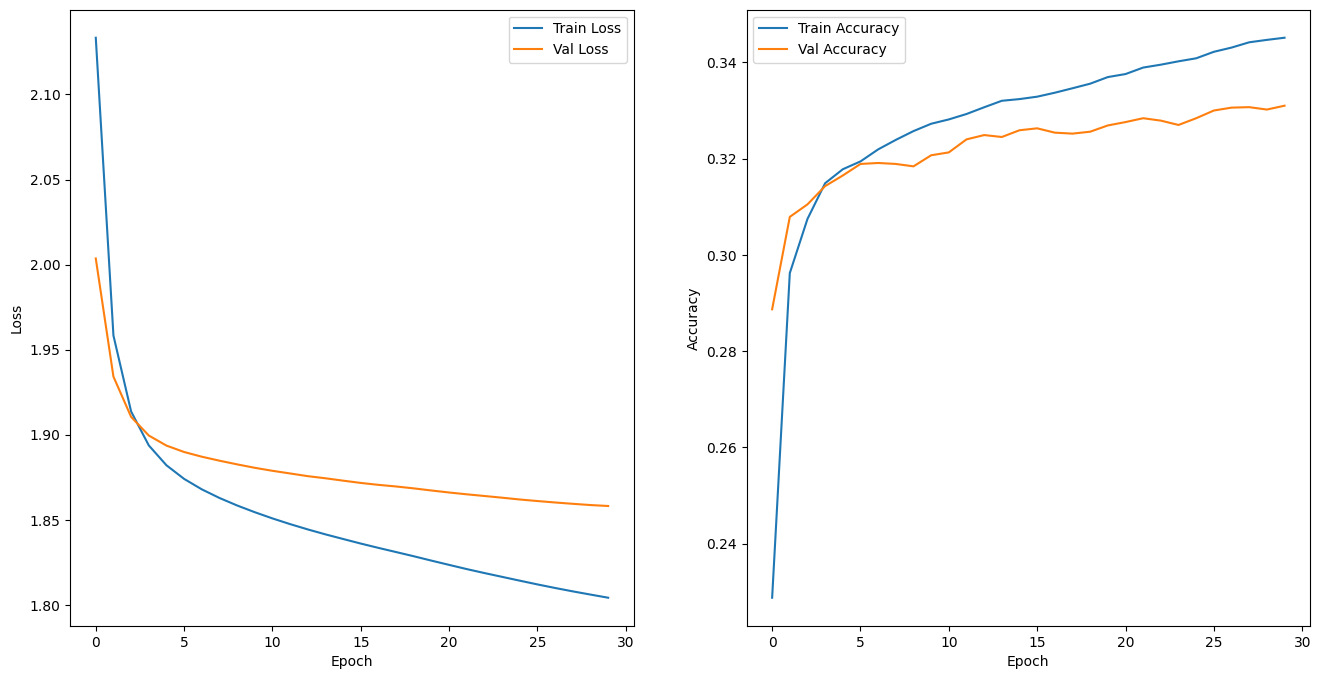

In [ ]:
plot_history(history)